In [12]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors, LocalOutlierFactor as LOF

from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [13]:
# load the main dataframe
nfl_df = pd.read_csv('nfl_gamelogs_vegas_2015-2024_NEW.csv')
print(nfl_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5246 entries, 0 to 5245
Data columns (total 91 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Season      5246 non-null   int64  
 1   Team        5246 non-null   object 
 2   Gtm         5246 non-null   float64
 3   Week        5246 non-null   float64
 4   Date        5246 non-null   object 
 5   Day         5246 non-null   object 
 6   Opp_x       5246 non-null   object 
 7   Win         5246 non-null   int64  
 8   Tm_Pts      5246 non-null   int64  
 9   Opp_Pts     5246 non-null   int64  
 10  OT          5246 non-null   int64  
 11  Tm_pCmp     5246 non-null   int64  
 12  Tm_pAtt     5246 non-null   int64  
 13  Tm_pCmp%    5246 non-null   float64
 14  Tm_pYds     5246 non-null   int64  
 15  Tm_pTD      5246 non-null   int64  
 16  Tm_pY/A     5246 non-null   float64
 17  Tm_pAY/A    5246 non-null   float64
 18  Tm_pRate    5246 non-null   float64
 19  Tm_Sk       5246 non-null  

In [14]:
# add a few columns
nfl_df['True_Total'] = nfl_df['Tm_Pts'] + nfl_df['Opp_Pts']
nfl_df['Under'] = np.where(nfl_df['True_Total'] < nfl_df['Total'], 1,0)
print(nfl_df)

      Season Team   Gtm  Week        Date  Day Opp_x  Win  Tm_Pts  Opp_Pts  \
0       2015  CRD   1.0   1.0  2015-09-13  Sun   NOR    1      31       19   
1       2015  CRD   2.0   2.0  2015-09-20  Sun   CHI    1      48       23   
2       2015  CRD   3.0   3.0  2015-09-27  Sun   SFO    1      47        7   
3       2015  CRD   4.0   4.0  2015-10-04  Sun   STL    0      22       24   
4       2015  CRD   5.0   5.0  2015-10-11  Sun   DET    1      42       17   
...      ...  ...   ...   ...         ...  ...   ...  ...     ...      ...   
5241    2024  WAS  13.0  13.0  2024-12-01  Sun   TEN    1      42       19   
5242    2024  WAS  14.0  15.0  2024-12-15  Sun   NOR    1      20       19   
5243    2024  WAS  15.0  16.0  2024-12-22  Sun   PHI    1      36       33   
5244    2024  WAS  16.0  17.0  2024-12-29  Sun   ATL    1      30       24   
5245    2024  WAS  17.0  18.0  2025-01-05  Sun   DAL    1      23       19   

      ...  Opp_TO  Opp_ToP  Home  Opp_y  Spread  Total  Cover  

In [15]:
nfl_df = nfl_df.sort_values(by=['Season','Week']).reset_index(drop=True)


Results for 2021:
 Week  1: accuracy score56.25%
 Week  2: accuracy score31.25%
 Week  3: accuracy score56.25%
 Week  4: accuracy score37.50%
 Week  5: accuracy score62.50%
 Week  6: accuracy score61.54%
 Week  7: accuracy score61.54%
 Week  8: accuracy score60.00%
 Week  9: accuracy score69.23%
 Week 10: accuracy score61.54%
 Week 11: accuracy score60.00%
 Week 12: accuracy score46.67%
 Week 13: accuracy score21.43%
 Week 14: accuracy score53.85%
 Week 15: accuracy score25.00%
 Week 16: accuracy score68.75%
 Week 17: accuracy score60.00%
 Week 18: accuracy score60.00%
Season 2021: Total accuracy score=52.63%

Classification Report for 2021:
              precision    recall  f1-score   support

        Over       0.49      0.49      0.49       124
       Under       0.56      0.56      0.56       142

    accuracy                           0.53       266
   macro avg       0.52      0.52      0.52       266
weighted avg       0.53      0.53      0.53       266



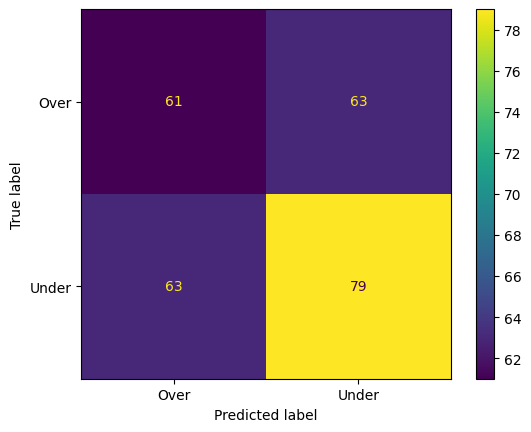


Results for 2022:
 Week  1: accuracy score68.75%
 Week  2: accuracy score31.25%
 Week  3: accuracy score73.33%
 Week  4: accuracy score56.25%
 Week  5: accuracy score56.25%
 Week  6: accuracy score64.29%
 Week  7: accuracy score69.23%
 Week  8: accuracy score35.71%
 Week  9: accuracy score38.46%
 Week 10: accuracy score50.00%
 Week 11: accuracy score50.00%
 Week 12: accuracy score68.75%
 Week 13: accuracy score42.86%
 Week 14: accuracy score53.85%
 Week 15: accuracy score31.25%
 Week 16: accuracy score35.71%
 Week 17: accuracy score69.23%
 Week 18: accuracy score50.00%
Season 2022: Total accuracy score=52.47%

Classification Report for 2022:
              precision    recall  f1-score   support

        Over       0.47      0.53      0.50       117
       Under       0.58      0.52      0.55       146

    accuracy                           0.52       263
   macro avg       0.52      0.53      0.52       263
weighted avg       0.53      0.52      0.53       263



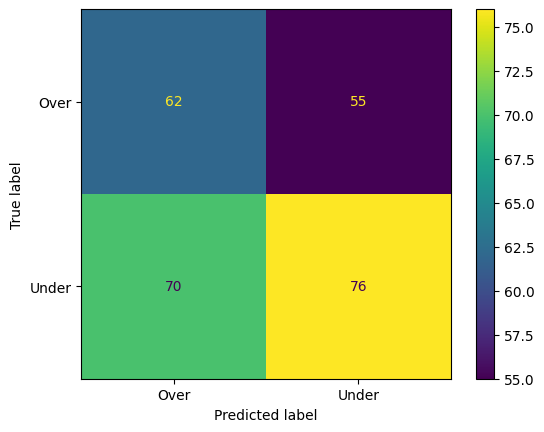


Results for 2023:
 Week  1: accuracy score80.00%
 Week  2: accuracy score56.25%
 Week  3: accuracy score62.50%
 Week  4: accuracy score68.75%
 Week  5: accuracy score71.43%
 Week  6: accuracy score64.29%
 Week  7: accuracy score69.23%
 Week  8: accuracy score53.33%
 Week  9: accuracy score57.14%
 Week 10: accuracy score61.54%
 Week 11: accuracy score50.00%
 Week 12: accuracy score62.50%
 Week 13: accuracy score50.00%
 Week 14: accuracy score58.33%
 Week 15: accuracy score46.15%
 Week 16: accuracy score35.71%
 Week 17: accuracy score50.00%
 Week 18: accuracy score42.86%
Season 2023: Total accuracy score=58.17%

Classification Report for 2023:
              precision    recall  f1-score   support

        Over       0.54      0.51      0.52       113
       Under       0.62      0.64      0.63       138

    accuracy                           0.58       251
   macro avg       0.58      0.58      0.58       251
weighted avg       0.58      0.58      0.58       251



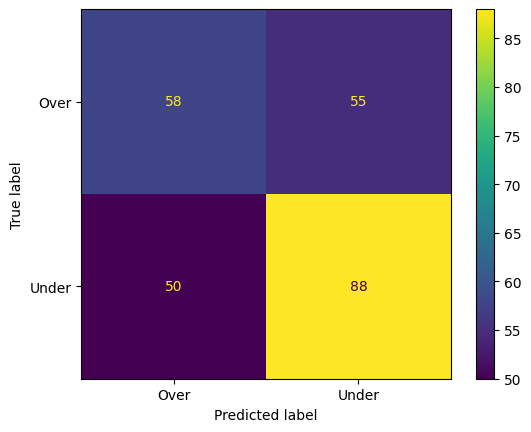


Results for 2024:
 Week  1: accuracy score46.67%
 Week  2: accuracy score53.33%
 Week  3: accuracy score46.67%
 Week  4: accuracy score62.50%
 Week  5: accuracy score42.86%
 Week  6: accuracy score38.46%
 Week  7: accuracy score53.33%
 Week  8: accuracy score62.50%
 Week  9: accuracy score60.00%
 Week 10: accuracy score61.54%
 Week 11: accuracy score42.86%
 Week 12: accuracy score76.92%
 Week 13: accuracy score56.25%
 Week 14: accuracy score53.85%
 Week 15: accuracy score35.71%
 Week 16: accuracy score43.75%
 Week 17: accuracy score66.67%
 Week 18: accuracy score46.67%
Season 2024: Total accuracy score=52.85%

Classification Report for 2024:
              precision    recall  f1-score   support

        Over       0.58      0.50      0.54       143
       Under       0.49      0.56      0.52       120

    accuracy                           0.53       263
   macro avg       0.53      0.53      0.53       263
weighted avg       0.53      0.53      0.53       263



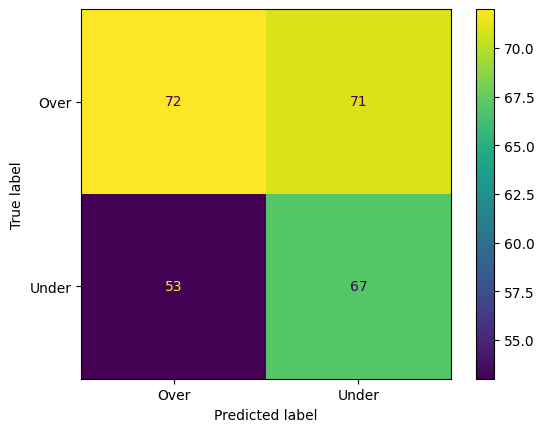

In [16]:
df = nfl_df.query('Home == 1').reset_index(drop=True)

# set features and target variable. NOTE: these could be any vaules you would like
features = ['Spread','Total']
target = 'Under'

# iterate over the last 3 seasons
for season in [2021, 2022, 2023, 2024]:
    
    print(f'\nResults for {season}:')

    # initalize the season aggregates
    y_preds = []
    y_trues = []
    
    for week in range(1,19):
        print(f' Week {week:>2}:', end=' ') 
        # create training set
        train_df = df.query('Season < @season or (Season == @season and Week < @week)')
        # create testing set
        test_df = df.query('Season == @season and Week == @week and True_Total != Total')
        
        X_train = train_df[features]
        y_train = train_df[target]
        X_test = test_df[features]
        y_test = test_df[target]

        # set the model 
        model = KNeighborsClassifier(n_neighbors=7)

        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('model', KNeighborsClassifier(n_neighbors=7))
        ])
        
        clf = pipe.fit(X_train, y_train)
        
        pipe2 = Pipeline([
            ('scaler', StandardScaler()),
            ('lof', LOF(novelty=True))
        ])
        pipe2.fit(X_train)
        y_test_novelty = pipe2.predict(X_test)
        mask = [ y == 1 for y in y_test_novelty]
        X_test = X_test[mask]
        y_test = y_test[mask]

        # get the predictions
        y_pred = clf.predict(X_test)
        
        if week == 1:
            y_test = test_df[target]
            y_pred = [1] * len(y_test)

        # get the true values
        y_true = y_test

        # display the accuracy score for the current week
        print(f'accuracy score{accuracy_score(y_true, y_pred):.2%}')

        # update the season aggregates
        y_preds += list(y_pred)
        y_trues += list(y_true)

    # display the total accuracy score for the current season
    print(f'Season {season}: Total accuracy score={accuracy_score(y_trues, y_preds):.2%}')

    # display the classification report for the current season
    print(f'\nClassification Report for {season}:')
    print(classification_report(y_trues, y_preds, target_names=['Over', 'Under']))

    # display the confusion matrix for the current season
    cm = confusion_matrix(y_trues, y_preds)
    display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Over', 'Under'])
    display.plot()
    plt.grid(False)
    plt.show()    
        

In [17]:
# make predictions for NFL Totals (Season = 2024, Week = 1)
# set the dataframe
df = nfl_df.query('Home == 1')

# set the features and the target variable
features = ['Spread','Total']
target = 'Under'

# set the season and the week
season = 2025
week = 5

# create training set
train_df = df.query('Season < @season or (Season == @season and Week < @week)')

# create X_train and y_train
X_train = train_df[features]
y_train = train_df[target]

# two-dimensional list with upcoming game data from the home team's perspective
# NOTE: this is the only thing you should change from week to week.
# If you changed the features, you would also add them here.
# week1 variable doesn't need to change, but you can change week = 5 to whatever week it is if you want.
week1 = [
    ['Buccaneers @ Falcons', -1.5, 43.5],
    ['Jets @ Vikings', -2.5, 40.5],
    ['Ravens @ Bengals', +2.5, 50.5],
    ['Dolphins @ Patriots', -1.5, 35.5],
    ['Bills @ Texans', -1.5, 46.5],
    ['Colts @ Jaguars', -2.5, 46.5],
    ['Browns @ Commanders', -3.0, 43.5],
    ['Panthers @ Bears', -3.5, 42.5],
    ['Cardinals @ 49ers', -7.5, 50.5],
    ['Raiders @ Broncos', -2.5, 36.5],
    ['Packers @ Rams', +3.5, 47.5],
    ['Giants @ Seahawks', -5.5, 41.5],
    ['Cowboys @ Steelers', -1.5, 42.5],
    ['Saints @ Chiefs', -5.5, 42.5]
]

# create X_new dataframe from the upcoming game data
X_new = pd.DataFrame(week1, columns=['Game','Spread','Total'])

# create a pipeline with scaler and model
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=7))
])

# train model
clf = pipe.fit(X_train, y_train)

# detect and remove novelty data from the new data
lof = LOF(novelty=True)
pipe2 = Pipeline([
    ('scaler', StandardScaler()),
    ('lof', LOF(novelty=True))
])

pipe2.fit(X_train)
y_test_novelty = pipe2.predict(X_new[features])

# create a mask for novelty data
mask = [y == 1 for y in y_test_novelty]

# remove the novelty games from the new dataset
X_new = X_new[mask]

# make the predictions with probabilities
y_pred_proba = clf.predict_proba(X_new[features])

# extract the probability of the Under prediction
X_new['Under_Prob'] = np.round(y_pred_proba[:, 1] * 100, 2)  # Convert to percentage

# make all Week 1 games Under
if week == 1:
    y_pred = [1] * len(X_new)
    
# add predictions to the dataframe
X_new['KNC(7)'] = clf.predict(X_new[features])
X_new['KNC(7)'] = X_new['KNC(7)'].apply(lambda x: 'Under' if x == 1 else 'Over')

# display the dataframe with the predictions
print(f'MODEL PREDICTIONS FOR WEEK {week} OF THE {season} NFL SEASON\n')
print(X_new[['Game', 'Spread', 'Total', 'KNC(7)', 'Under_Prob']])

MODEL PREDICTIONS FOR WEEK 5 OF THE 2025 NFL SEASON

                    Game  Spread  Total KNC(7)  Under_Prob
0   Buccaneers @ Falcons    -1.5   43.5  Under       57.14
1         Jets @ Vikings    -2.5   40.5   Over       28.57
2       Ravens @ Bengals     2.5   50.5   Over       42.86
3    Dolphins @ Patriots    -1.5   35.5  Under       57.14
4         Bills @ Texans    -1.5   46.5  Under       57.14
5        Colts @ Jaguars    -2.5   46.5   Over       42.86
6    Browns @ Commanders    -3.0   43.5  Under       71.43
7       Panthers @ Bears    -3.5   42.5  Under       57.14
8      Cardinals @ 49ers    -7.5   50.5  Under       71.43
9      Raiders @ Broncos    -2.5   36.5  Under       57.14
10        Packers @ Rams     3.5   47.5  Under       57.14
11     Giants @ Seahawks    -5.5   41.5  Under       71.43
12    Cowboys @ Steelers    -1.5   42.5   Over       42.86
13       Saints @ Chiefs    -5.5   42.5  Under       57.14
